# Execute the code below

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

df_weather = pd.read_csv("..\Data\weather2019.csv")
df_weather = df_weather.iloc[:,[0,1,2, -4]]

# Univariate linear regression with Scikit-Learn

Scikit-Learn is the greatest Machine Learning library for Python. Do you remember that you can do Linear regression with NumPy ? You can do the same with Scikit-Learn. And many other things!
Let's start with univariate Linear regression, to learn the syntax.

## Print a regplot with seaborn to show a linear regression between Sunhours (on the X-axis) and MAX temperature (on the Y-axis).

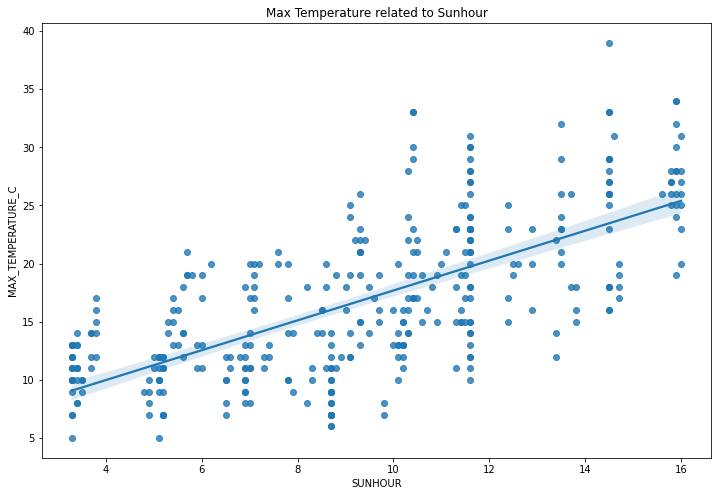

In [6]:
# Your code here :
plt.figure(figsize=(12, 8))
# regplot from Seaborn that shows relation between Max Temperature C and Sunhour
sns.regplot(data = df_weather,
            x = "SUNHOUR",
            y = "MAX_TEMPERATURE_C")


# show a clean visualisation with title :
plt.title('Max Temperature related to Sunhour')
plt.show()

## Train the model
You just have to read and execute the code below

In [ ]:
# Scikit-Learn can find the coefficients of the linear regression
from sklearn.linear_model import LinearRegression

# First of all, you have to define 2 series :
# X-axis : the correlated column, here it is Sunhours
X = df_weather[['SUNHOUR']]

# Y-axis : the column to predict, so MAX Temperature here
y = df_weather['MAX_TEMPERATURE_C']


# To train a machine learning model (here, it will find the equation of the linear regression), you just have launch the ".fit" method.
modelLR = LinearRegression().fit(X, y)

## Explore the model

In [8]:
# Your model is trained, it has now some attributes.
# Coefficient, it's the "a" in your equation "aX + b"
print("coefficient :",modelLR.coef_)

# Interception, it's the "b" in your equation "aX + b"
print("intercept :", modelLR.intercept_)


coefficient : [1.28422116]
intercept : 4.8472953557195435


## Prediction for 1 value

In [6]:
# You can "predict" the Max Temperature from the Sunhours
# For example, let's try if Sunhours is 10 :

# Hand calculation :
print("By hand :", modelLR.coef_ * 10 + modelLR.intercept_ )

# With a Scikit-Learn function :
print("Scikit-Learn :  ", modelLR.predict([[10]])  )

By hand : [17.68950691]
Scikit-Learn :   [17.68950691]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Predictions for multiple values (a Serie)
Let's predict MAX temperature for the Sunhour column of your DataFrame.

Note : You'll have to precise your column with double "[", like that  : df[['your_column]]


In [7]:
# Find a way to store the result of the prediction in a new column 'predict" of the dataframe
df_weather['predict'] = modelLR.predict(df_weather[['SUNHOUR']])

# If we want we can check that the columns has been added
df_weather.info()
df_weather.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DATE               365 non-null    object 
 1   MAX_TEMPERATURE_C  365 non-null    int64  
 2   MIN_TEMPERATURE_C  365 non-null    int64  
 3   SUNHOUR            365 non-null    float64
 4   predict            365 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 14.4+ KB


,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,SUNHOUR,predict
0,2019-01-01,9,4,5.1,11.396823
1,2019-01-02,8,5,8.7,16.020019
2,2019-01-03,6,0,8.7,16.020019
3,2019-01-04,5,-1,5.1,11.396823
4,2019-01-05,6,-1,8.7,16.020019


## Visualisations
You can predict the Max temperature from any value of Sunhour. Your prediction is now stored in a column, you can now visualize it.

It's to you now :
Create on the same scatterplot chart :
- X-axis : Sunhours
- Y-axis : MAX temperatures in blue dots and 'predict' in red dots.

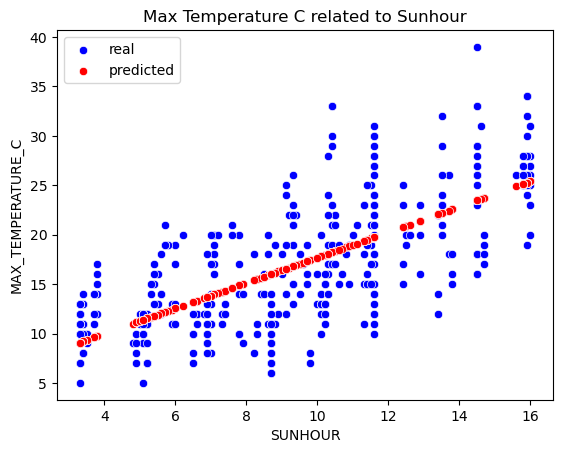

In [8]:
# Your code here :

# scatterplot from Seaborn that shows real Max Temperature C related to Sunhour in blue
sns.scatterplot(data = df_weather,
            x = "SUNHOUR",
            y = "MAX_TEMPERATURE_C",
            color = 'blue',
            label = 'real')  # add a label to show a legend on your visualisation

# scatterplot from Seaborn that shows predicted Max Temperature C related to Sunhour in red
sns.scatterplot(data = df_weather,
            x = "SUNHOUR",
            y = "predict",
            color = 'red',
            label = 'predicted')

# to show a clean visualisation with title and legend :
plt.title('Max Temperature C related to Sunhour')
plt.legend()
plt.show()

Your prediction is stored in a DataFrame. **So, you can visualize your prediction without the "source" column.** Let's try it.
Create on the same scatterplot chart :
- X-axis : DATE
- Y-axis : MAX temperatures in blue dots and 'predict' in red dots.

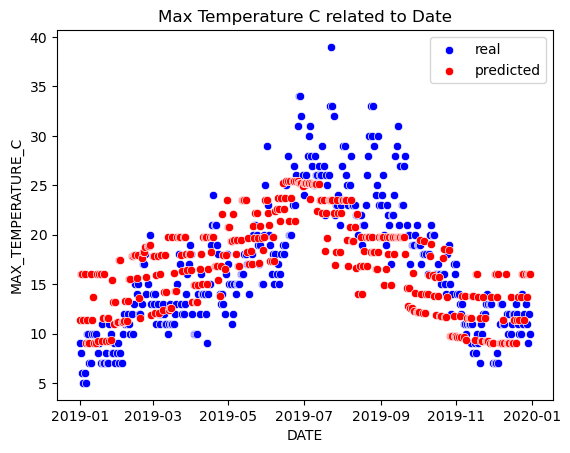

In [9]:
# Your code here :

# convert dates (string) into date format with pd.to_datetime
df_weather['DATE'] = pd.to_datetime(df_weather['DATE'])

# scatterplot from Seaborn that shows real Max Temperature C related to Date in blue
sns.scatterplot(data = df_weather,
            x = "DATE",
            y = "MAX_TEMPERATURE_C",
            color = 'blue',
            label = 'real')  # add a label to show a legend on your visualisation

# scatterplot from Seaborn that shows predicted Max Temperature C (predicted from Sunhour) related to Date in red
sns.scatterplot(data = df_weather,
            x = "DATE",
            y = "predict",
            color = 'red',
            label = 'predicted')

# to show a clean visualisation with title and legend :
plt.title('Max Temperature C related to Date')
plt.legend()
plt.show()

Hey, but it doesn't seem linear ! And yet it is...

# Predictions on a more correlated column
Do the same steps to obtain a new colum "predict2". Your goal is to predict "MAX temperature" from the "MIN temperature" column.

In [10]:
# Your code here :

## definition of the 2 series :

# X-axis : the correlated column, here it is MIN temperature :
X = df_weather[['MIN_TEMPERATURE_C']]

# Y-axis : the column to predict, so MAX Temperature here :
y = df_weather['MAX_TEMPERATURE_C']

# Train the machine learning method :
modelLR1 = LinearRegression().fit(X, y)


## Exploration of the model :
print("coefficient :",modelLR1.coef_)

# Interception, it's the "b" in your equation "aX + b"
print("intercept :", modelLR1.intercept_)



## Prediction for one value :
# For example, let's try if MIN temperature is 10 :

# Hand calculation :
print("By hand :", modelLR1.coef_ * 10 + modelLR.intercept_ )

# With a Scikit-Learn function :
print("Scikit-Learn :  ", modelLR1.predict([[10]]))


coefficient : [1.22274205]
intercept : 5.689031214578716
By hand : [17.07471586]
Scikit-Learn :   [17.91645172]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [11]:
## Prediction for several values :

df_weather['predict2'] = modelLR1.predict(df_weather[['MIN_TEMPERATURE_C']])

# If we want we can check that the columns has been added
df_weather.info()
df_weather.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   DATE               365 non-null    datetime64[ns]
 1   MAX_TEMPERATURE_C  365 non-null    int64         
 2   MIN_TEMPERATURE_C  365 non-null    int64         
 3   SUNHOUR            365 non-null    float64       
 4   predict            365 non-null    float64       
 5   predict2           365 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 17.2 KB


,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,SUNHOUR,predict,predict2
0,2019-01-01,9,4,5.1,11.396823,10.579999
1,2019-01-02,8,5,8.7,16.020019,11.802741
2,2019-01-03,6,0,8.7,16.020019,5.689031
3,2019-01-04,5,-1,5.1,11.396823,4.466289
4,2019-01-05,6,-1,8.7,16.020019,4.466289


## Scatterplot 1
- X-axis : MIN temperature
- Y-axis : MAX temperatures in blue dots and 'predict2' in red dots.

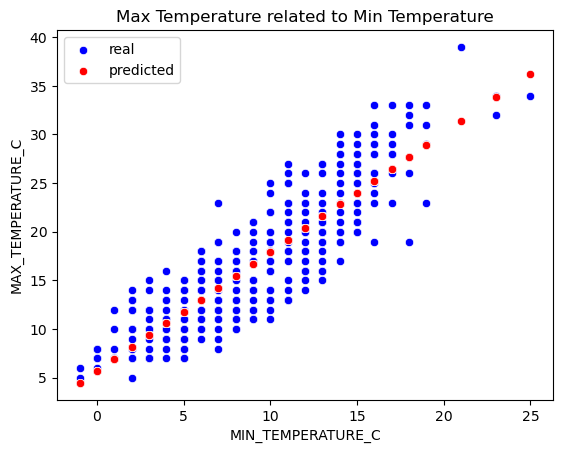

In [12]:
#Your code here :

# scatterplot from Seaborn that shows real Max Temperature C related to Min Temperature C in blue
sns.scatterplot(data = df_weather,
                x = 'MIN_TEMPERATURE_C',
                y = 'MAX_TEMPERATURE_C',
                color = 'blue',
                label = 'real')  # add a label to show a legend on your visualisation

# scatterplot from Seaborn that shows predicted Max Temperature C related to Min Temperature C in red
sns.scatterplot(data = df_weather,
                x = 'MIN_TEMPERATURE_C',
                y = 'predict2',
                color = 'red',
                label = 'predicted')

# to show a clean visualisation with title and legend :
plt.title('Max Temperature related to Min Temperature')
plt.legend()
plt.show()

## Scatterplot 2
- X-axis : DATE
- Y-axis : MAX temperatures in blue dots and 'predict2' in red dots.

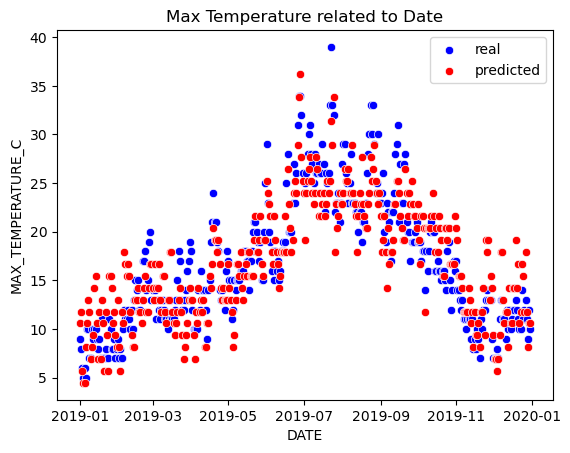

In [13]:
# Your code here :

# scatterplot from Seaborn that shows real Max Temperature C related to Date in blue
sns.scatterplot(data = df_weather,
                x = 'DATE',
                y = 'MAX_TEMPERATURE_C',
                color = 'blue',
                label ='real')  # add a label to show a legend on your visualisation

# scatterplot from Seaborn that shows predicted Max Temperature C (predicted from Min Temperature C) related to Date in blue
sns.scatterplot(data = df_weather,
                x = 'DATE',
                y = 'predict2',
                color = 'red',
                label ='predicted')

# to show a clean visualisation with title and legend :
plt.title('Max Temperature related to Date')
plt.legend()
plt.show()